In [8]:
# install FRED api (Federal Reserve Bank at St Louis)
!pip install fredapi

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Yahoo és FRED csomagok
import yfinance as yf
from fredapi import Fred
from google.colab import userdata

FRED_API_KEY = userdata.get('MY_FRED')
fred = Fred(api_key=FRED_API_KEY)

# Infláció - tényadat (CPIAUCSL)
Mivel utólag módosították, pontosították az adatokat azért hogy lekerüljük a jövőbe látást az első olyan adatot és dátumot tartjuk meg, ami az adott hónapra vonatkozik.

In [9]:
df_all = fred.get_series_all_releases('CPIAUCSL')

# Adattisztítás
df_all = df_all.sort_values(by=['date', 'realtime_start'])
df_first_release = df_all.drop_duplicates(subset='date', keep='first').copy()
df_first_release['release_date'] = pd.to_datetime(df_first_release['realtime_start'])
df_first_release['target_month'] = pd.to_datetime(df_first_release['date'])

df_CPIAUCSL = df_first_release[['release_date', 'target_month', 'value']]
df_CPIAUCSL = df_CPIAUCSL.sort_values('release_date')
df_CPIAUCSL['Future CPI'] = df_CPIAUCSL['value'].shift(-1)
display(df_CPIAUCSL)


,release_date,target_month,value,Future CPI
332,1972-07-21,1972-02-01,124.06,124.31
340,1972-07-21,1972-04-01,124.31,124.1
336,1972-07-21,1972-03-01,124.1,123.36
329,1972-07-21,1972-01-01,123.36,123.0
325,1972-07-21,1971-12-01,123.0,122.62
...,...,...,...,...
3350,2025-12-18,2025-11-01,325.031,326.03
3352,2026-01-13,2025-12-01,326.03,326.588
3354,2026-02-13,2026-01-01,326.588,327.46
3355,2026-03-11,2026-02-01,327.46,330.293


# Infláció - előrejelzés (InfNowcast)

In [10]:
import pandas as pd
import glob
import os
import re
import requests
import io

api_url = "https://api.github.com/repos/siklerjulianna/TDK-MBL/contents/Data_FRED/FRED_InflNowcast"
response = requests.get(api_url)

all_items = response.json()
csv_files = []

for item in all_items:
    if item['name'].endswith('.csv'):
        # Kikeressük az évet és hónapot a rendezéshez
        match = re.search(r'-(\d{4})-(\d{1,2})\.csv$', item['name'])
        if match:
          # Elmentjük a fájl infóit és a számértékeket a rendezéshez
          csv_files.append({
              'info': item,
              'year': int(match.group(1)),
              'month': int(match.group(2))
          })
# Rendezés év, hónap szerint
csv_files.sort(key=lambda x: (x['year'], x['month']))

sorted_files = [f['info'] for f in csv_files]

nowcast_list = []
print(f"{len(sorted_files)} fájl feldolgozása folyamatban...")


for file_info in sorted_files:
    filename = file_info['name']
    download_url = file_info['download_url']
    # Év és hónap kinyerése a fájlnévből
    match = re.search(r'-(\d{4})-(\d{1,2})', filename)
    if match:
        file_year = match.group(1)
        file_month = match.group(2)

        # Fájl beolvasása
        file_res = requests.get(download_url)
        df = pd.read_csv(io.StringIO(file_res.text))

        # Dátum korrekció
        df['prediction_date'] = pd.to_datetime(file_year + '/' + df['Label'], format='%Y/%m/%d')

        # Célhónap (target_month) hozzáadása
        # Ez az az év/hónap, amire a várakozás vonatkozik (szintén a fájlnévből)
        df['target_month'] = pd.to_datetime(f"{file_year}-{file_month}-01")

        # Eredeti Label oszlop eldobása, mert már megvan a prediction_date
        df = df.drop(columns=['Label'])
        nowcast_list.append(df)

df_InflNowcast = pd.concat(nowcast_list, ignore_index=True)
df_InflNowcast = df_InflNowcast.drop_duplicates(subset=['target_month', 'prediction_date'])

display(df_InflNowcast)

150 fájl feldolgozása folyamatban...


,CPI Inflation,Core CPI Inflation,PCE Inflation,Core PCE Inflation,prediction_date,target_month
0,0.393687,0.147090,0.250694,0.103589,2013-09-03,2013-09-01
1,0.312851,0.147090,0.203974,0.103589,2013-09-04,2013-09-01
2,0.312851,0.147090,0.203974,0.103589,2013-09-05,2013-09-01
3,0.312851,0.147090,0.203974,0.103589,2013-09-06,2013-09-01
4,0.312851,0.147090,0.203974,0.103589,2013-09-09,2013-09-01
...,...,...,...,...,...,...
6260,0.220594,0.199187,0.229981,0.226877,2026-02-12,2026-02-01
6261,0.222389,0.207034,0.229006,0.228993,2026-02-13,2026-02-01
6262,0.222389,0.207034,0.229006,0.228993,2026-02-17,2026-02-01
6263,0.222389,0.207034,0.229006,0.228993,2026-02-18,2026-02-01


In [11]:
def get_waiting_for_month(query_date):
    # Megmondja, melyik az a hónap, aminek az inflációs adatát éppen várja a piac az adott napon
    query_date = pd.to_datetime(query_date)

    # Keressük meg az adott napot megelőző közléseket
    past_releases = df_CPIAUCSL[df_CPIAUCSL['release_date'] <= query_date]

    if past_releases.empty:
        return None

    # Az utolsó megjelent adat hónapja
    last_released_month = past_releases.iloc[-1]['target_month']

    waiting_for = last_released_month + pd.DateOffset(months=1)
    return waiting_for

df_InflNowcast['waiting_for'] = df_InflNowcast['prediction_date'].apply(get_waiting_for_month)
df_InflNowcast = df_InflNowcast[df_InflNowcast['target_month'] == df_InflNowcast['waiting_for']].copy()
display(df_InflNowcast)

,CPI Inflation,Core CPI Inflation,PCE Inflation,Core PCE Inflation,prediction_date,target_month,waiting_for
10,0.272673,0.146001,0.181965,0.103580,2013-09-17,2013-09-01,2013-09-01
11,0.272673,0.146001,0.181965,0.103580,2013-09-18,2013-09-01,2013-09-01
12,0.272673,0.146001,0.181965,0.103580,2013-09-19,2013-09-01,2013-09-01
13,0.272673,0.146001,0.181965,0.103580,2013-09-20,2013-09-01,2013-09-01
14,0.272673,0.146001,0.181965,0.103580,2013-09-23,2013-09-01,2013-09-01
...,...,...,...,...,...,...,...
6247,0.134979,0.218199,0.175794,0.233642,2026-02-12,2026-01-01,2026-01-01
6261,0.222389,0.207034,0.229006,0.228993,2026-02-13,2026-02-01,2026-02-01
6262,0.222389,0.207034,0.229006,0.228993,2026-02-17,2026-02-01,2026-02-01
6263,0.222389,0.207034,0.229006,0.228993,2026-02-18,2026-02-01,2026-02-01


In [12]:
# Tényadat és várakozás adatsorok egyesítése egy adatbázisba
df_InflationAE = df_InflNowcast.merge(
    df_CPIAUCSL,
    left_on='prediction_date',
    right_on='release_date',
    how='left')

# Adattisztítás
df_InflationAE['value'] = df_InflationAE['value'].ffill()
df_InflationAE = df_InflationAE[['target_month_x','CPI Inflation','Core CPI Inflation','prediction_date','release_date','value','Future CPI']]
df_InflationAE = df_InflationAE.sort_index()

# ffill() alkalmazása a release_date-re egy segédoszlopba
# Ez megmondja minden napra, hogy mikor volt az utolsó hivatalos inflációs közlés
df_InflationAE['next_actual_release'] = df_InflationAE['release_date'].bfill()

# Maskot készítünk az érvényes dátumokhoz
valid_mask = df_InflationAE['next_actual_release'].notna() & df_InflationAE['prediction_date'].notna()

# Csak az érvényes sorokon futtatjuk a számítást
df_InflationAE.loc[valid_mask, 'days_left'] = np.busday_count(
    df_InflationAE.loc[valid_mask, 'prediction_date'].values.astype('datetime64[D]'),
    df_InflationAE.loc[valid_mask, 'next_actual_release'].values.astype('datetime64[D]')
).astype(float)

df_InflationAE = df_InflationAE.rename(columns={
    'target_month_x' : 'target_month',
    'CPI Inflation': 'CPI Nowcast',
    'Core CPI Inflation': 'Core CPI Nowcast',
    'prediction_date': 'Date',
    'value': 'Actual CPI',
    'Future CPI':'Future CPI'
})

df_InflationAE = df_InflationAE.set_index('Date')

# "hozamosítás"
df_InflationAE['Actual CPI'] = df_InflationAE['Actual CPI'].pct_change() * 100
df_InflationAE['Future CPI'] = df_InflationAE['Future CPI'].pct_change() * 100

display(df_InflationAE)

/tmp/ipykernel_20423/3008033814.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_InflationAE['value'] = df_InflationAE['value'].ffill()
/tmp/ipykernel_20423/3008033814.py:39: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_InflationAE['Future CPI'] = df_InflationAE['Future CPI'].pct_change() * 100
/tmp/ipykernel_20423/3008033814.py:39: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_

,target_month,CPI Nowcast,Core CPI Nowcast,release_date,Actual CPI,Future CPI,next_actual_release,days_left
Date,,,,,,,,
2013-09-17,2013-09-01,0.272673,0.146001,2013-09-17,NaN,NaN,2013-09-17,0.0
2013-09-18,2013-09-01,0.272673,0.146001,NaT,0.00000,0.000000,2013-10-30,30.0
2013-09-19,2013-09-01,0.272673,0.146001,NaT,0.00000,0.000000,2013-10-30,29.0
2013-09-20,2013-09-01,0.272673,0.146001,NaT,0.00000,0.000000,2013-10-30,28.0
2013-09-23,2013-09-01,0.272673,0.146001,NaT,0.00000,0.000000,2013-10-30,27.0
...,...,...,...,...,...,...,...,...
2026-02-12,2026-01-01,0.134979,0.218199,NaT,0.00000,0.000000,2026-02-13,1.0
2026-02-13,2026-02-01,0.222389,0.207034,2026-02-13,0.17115,0.267003,2026-02-13,0.0
2026-02-17,2026-02-01,0.222389,0.207034,NaT,0.00000,0.000000,NaT,NaN


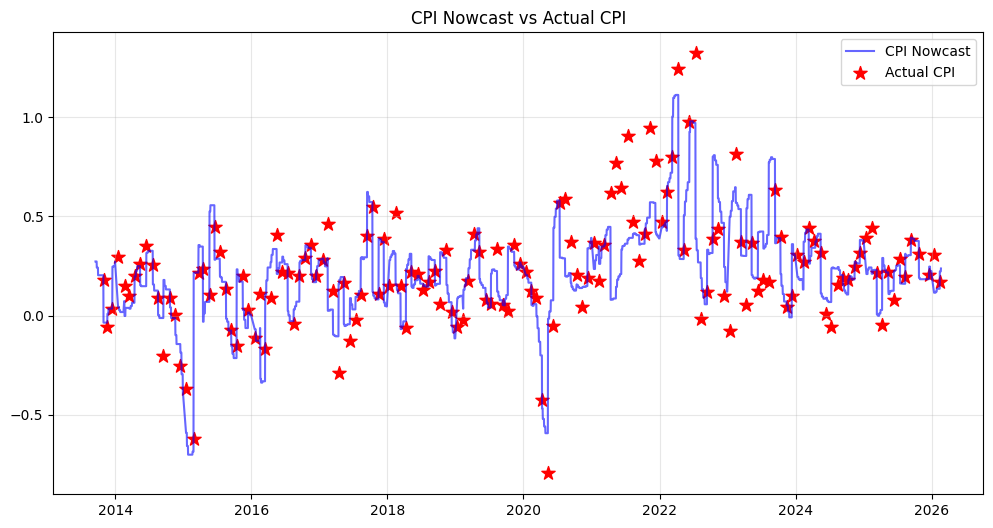

In [13]:
plt.figure(figsize=(12, 6))
plt.plot(df_InflationAE.index, df_InflationAE['CPI Nowcast'], label='CPI Nowcast', color='blue', alpha=0.6)
# Actual CPI csillaggal
actuals = df_InflationAE[df_InflationAE['Actual CPI'] != 0]
plt.scatter(actuals.index, actuals['Actual CPI'], color='red', marker='*', s=100, label='Actual CPI')

plt.title('CPI Nowcast vs Actual CPI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

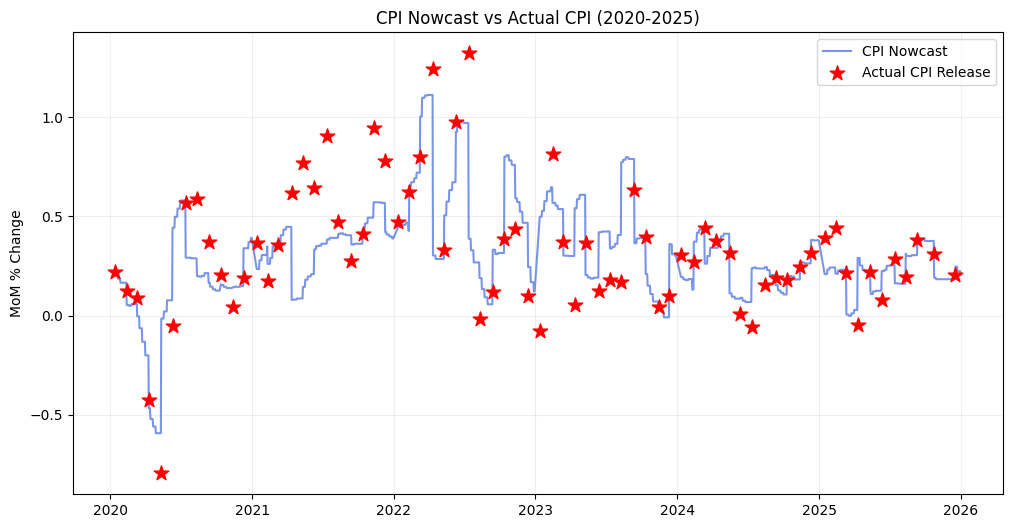

In [14]:
df_zoom = df_InflationAE.loc['2020-01-01':'2025-12-31']

# Csak a közlési napok kiválogatása a szűrt adatokból
actuals_zoom = df_zoom[df_zoom['Actual CPI'] != 0]

plt.figure(figsize=(12, 6))
# Kék vonal a folyamatos Nowcastnek
plt.plot(df_zoom.index, df_zoom['CPI Nowcast'], label='CPI Nowcast', color='royalblue', alpha=0.7)
# Piros csillagok a tényadatoknak
plt.scatter(actuals_zoom.index, actuals_zoom['Actual CPI'],
            color='red', marker='*', s=120, label='Actual CPI Release', zorder=5)
plt.title('CPI Nowcast vs Actual CPI (2020-2025)')
plt.ylabel('MoM % Change')
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

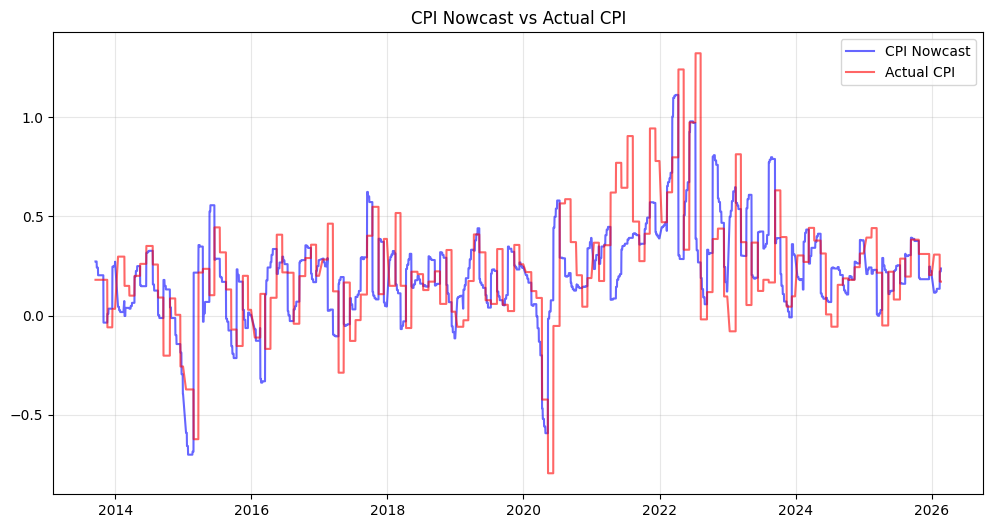

In [15]:
# A 0-kat átalakítjuk valódi hiányzó adattá (NaN)
df_InflationAE['Actual CPI'] = df_InflationAE['Actual CPI'].replace(0, np.nan)
df_InflationAE['Future CPI'] = df_InflationAE['Future CPI'].replace(0, np.nan)
# Most már a ffill()
df_InflationAE['Actual CPI'] = df_InflationAE['Actual CPI'].ffill()
df_InflationAE['Future CPI'] = df_InflationAE['Future CPI'].ffill()
# Az elején maradt esetleges NaN-okat is feltöltjük
df_InflationAE['Actual CPI'] = df_InflationAE['Actual CPI'].bfill()
df_InflationAE['Future CPI'] = df_InflationAE['Future CPI'].bfill()
#display(df_InflationAE)

# Ábrázolás: tényadat és előrejelzés
plt.figure(figsize=(12, 6))
plt.plot(df_InflationAE.index, df_InflationAE['CPI Nowcast'] , label='CPI Nowcast', color='blue', alpha=0.6)
plt.plot(df_InflationAE['Actual CPI'] , label='Actual CPI', color='red', alpha=0.6)

plt.title('CPI Nowcast vs Actual CPI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

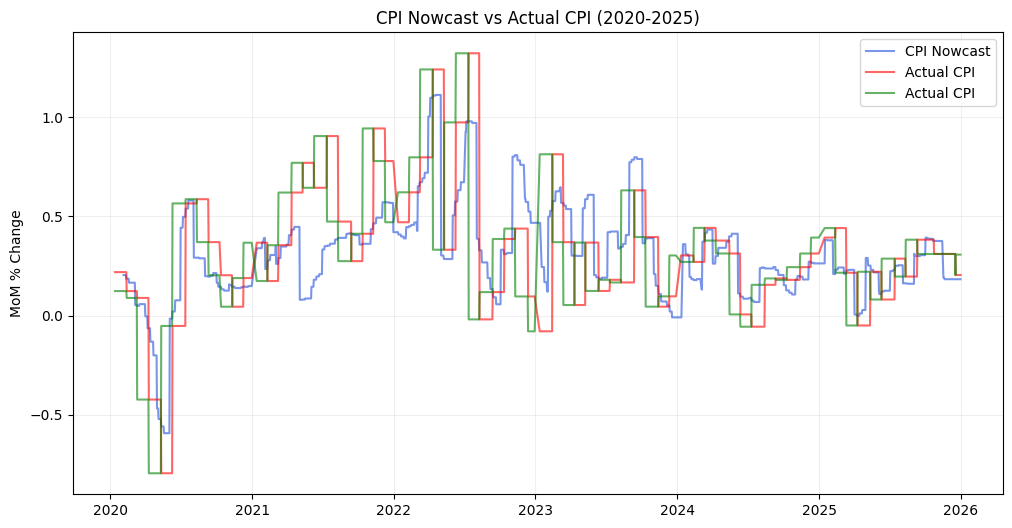

In [16]:
df_zoom = df_InflationAE.loc['2020-01-01':'2025-12-31']

# Ábrázolás: tényadat és előrejelzés időbeli elcsúszása
plt.figure(figsize=(12, 6))
plt.plot(df_zoom.index, df_zoom['CPI Nowcast'].shift(15) , label='CPI Nowcast', color='royalblue', alpha=0.7)
plt.plot(df_zoom['Actual CPI'], label='Actual CPI', color='red', alpha=0.6)
plt.plot(df_zoom['Future CPI'], label='Actual CPI', color='green', alpha=0.6)
plt.title('CPI Nowcast vs Actual CPI (2020-2025)')
plt.ylabel('MoM % Change')
plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

# Variancia

Az Inflation Nowcasting szakirodalom alapjan 2 évre visszamenőleg becsüljük a varianciát.

Gördülő ablakos RMSE számítás, 1 napos intervallum szerint

In [17]:
def calculate_nowcast_uncertainty(df, window_months=24):
    df_res = df.copy()

    # Négyzetes hibák kiszámítása
    df_res['SQ_Error_CPI'] = (df_res['CPI Nowcast'] - df_res['Future CPI'])**2
    df_res['SQ_Error_Core'] = (df_res['Core CPI Nowcast'] - df_res['Future CPI'])**2

    # Horizont alapú gördülő RMSE számítása
    # Csoportosítunk horizont szerint, majd minden horizonton belül 24 hónapot (2 évet) nézünk vissza
    results = []
    for horizon, group in df_res.groupby('days_left'):
        group = group.sort_values('target_month')

        group['RMSE_CPI'] = np.sqrt(
            group['SQ_Error_CPI'].shift(1).rolling(window=window_months, min_periods=1).mean()
        )
        group['RMSE_Core'] = np.sqrt(
            group['SQ_Error_Core'].shift(1).rolling(window=window_months, min_periods=1).mean()
        )
        results.append(group)

    # Adatok összefűzése és eredeti sorrend visszaállítása
    df_final = pd.concat(results).sort_index()
    return df_final

# Futtatás
df_InflationAE = calculate_nowcast_uncertainty(df_InflationAE)

display(df_InflationAE[['target_month', 'days_left', 'RMSE_CPI', 'Actual CPI','Future CPI']])

,target_month,days_left,RMSE_CPI,Actual CPI,Future CPI
Date,,,,,
2013-09-17,2013-09-01,0.0,NaN,0.180280,-0.059415
2013-09-18,2013-09-01,30.0,NaN,0.180280,-0.059415
2013-09-19,2013-09-01,29.0,NaN,0.180280,-0.059415
2013-09-20,2013-09-01,28.0,NaN,0.180280,-0.059415
2013-09-23,2013-09-01,27.0,NaN,0.180280,-0.059415
...,...,...,...,...,...
2026-02-09,2026-01-01,4.0,0.078537,0.307355,0.171150
2026-02-10,2026-01-01,3.0,0.084907,0.307355,0.171150
2026-02-11,2026-01-01,2.0,0.086878,0.307355,0.171150


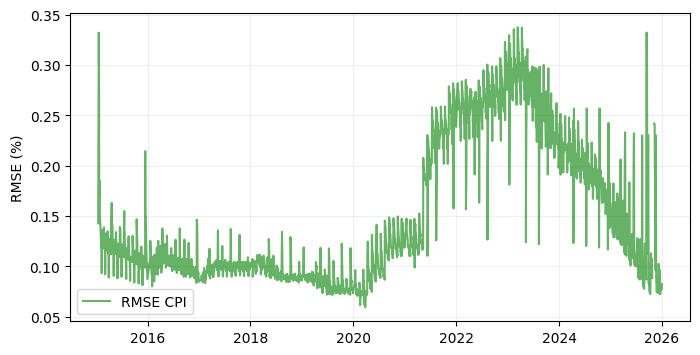

In [18]:
df_zoom = df_InflationAE.loc['2015-01-01':'2025-12-31']

# Ábrázolás: RMSE alakulása
plt.figure(figsize=(8, 4))
plt.plot(df_zoom['RMSE_CPI'], label='RMSE CPI', color='green', alpha=0.6)
plt.ylabel('RMSE (%)')
plt.grid(True, alpha=0.2)
plt.legend()

plt.show()

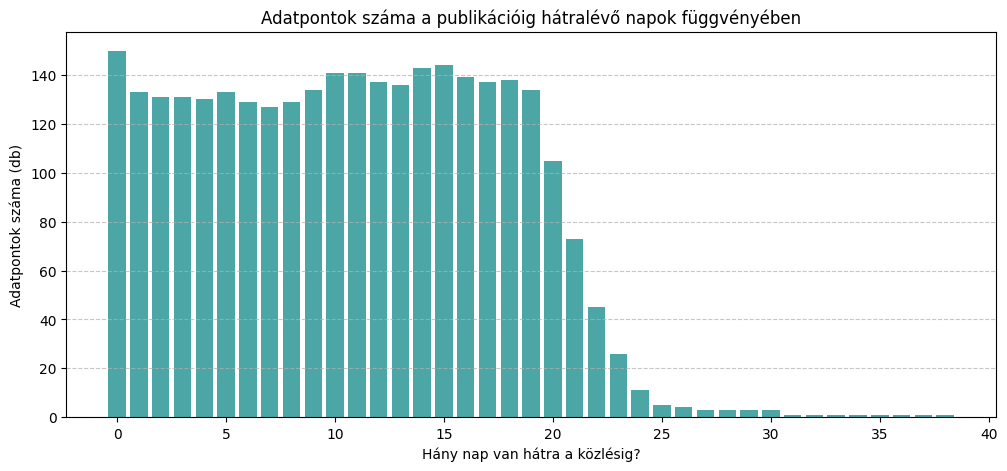

In [19]:
# Ábrázolás: adatpontok száma a publikációig hátralévő napok függvényében
horizon_counts = df_InflationAE['days_left'].value_counts().sort_index()

df_counts = horizon_counts.reset_index()
df_counts.columns = ['Napok a közlésig', 'Gyakoriság (db)']

plt.figure(figsize=(12, 5))
plt.bar(df_counts['Napok a közlésig'], df_counts['Gyakoriság (db)'], color='teal', alpha=0.7)
plt.title('Adatpontok száma a publikációig hátralévő napok függvényében')
plt.xlabel('Hány nap van hátra a közlésig?')
plt.ylabel('Adatpontok száma (db)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Gördülő ablakos RMSE számítás, több napos intervallumok szerint

In [20]:
# +- 2 napos intervallum
def get_rmse(row, df):
    # Csak a már publikált, azonos horizontú (+/- 2 nap) hibákat nézzük az elmúlt 2 évből
    mask = (df['next_actual_release'] < row.name) & \
           (df['target_month'] >= row['target_month'] - pd.DateOffset(months=24)) & \
           (df['days_left'].between(row['days_left'] - 2, row['days_left'] + 2))

    sq_errors = (df.loc[mask, 'CPI Nowcast'] - df.loc[mask, 'Future CPI'])**2
    return np.sqrt(sq_errors.mean()) if not sq_errors.empty else np.nan

# Alkalmazzuk minden napra
df_InflationAE['RMSE_CPI2'] = df_InflationAE.apply(get_rmse, axis=1, args=(df_InflationAE,))
df_InflationAE['RMSE_CPI2'] = df_InflationAE['RMSE_CPI2'].ffill().bfill()
df_InflationAE['CPI Nowcast Var'] = df_InflationAE['RMSE_CPI2']**2 # nézet varianciája

#display(df_InflationAE)

In [21]:
# +- 3 napos intervallum
def get_rmse(row, df):
    # Csak a már publikált, azonos horizontú (+/- 3 nap) hibákat nézzük az elmúlt 2 évből
    mask = (df['next_actual_release'] < row.name) & \
           (df['target_month'] >= row['target_month'] - pd.DateOffset(months=24)) & \
           (df['days_left'].between(row['days_left'] - 3, row['days_left'] + 3))

    sq_errors = (df.loc[mask, 'CPI Nowcast'] - df.loc[mask, 'Future CPI'])**2
    return np.sqrt(sq_errors.mean()) if not sq_errors.empty else np.nan

# Alkalmazzuk minden napra
df_InflationAE['RMSE_CPI3'] = df_InflationAE.apply(get_rmse, axis=1, args=(df_InflationAE,))
df_InflationAE['RMSE_CPI3'] = df_InflationAE['RMSE_CPI3'].ffill().bfill()

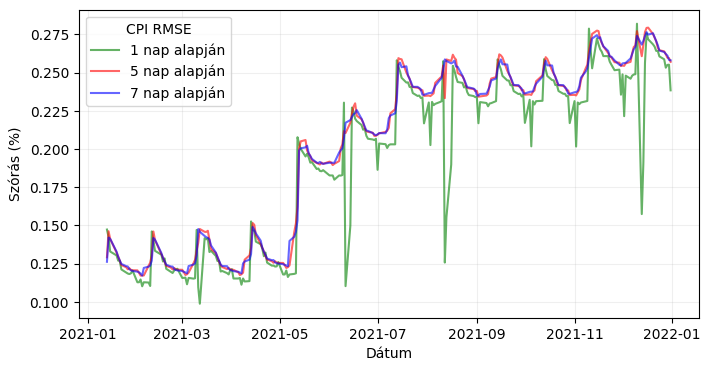

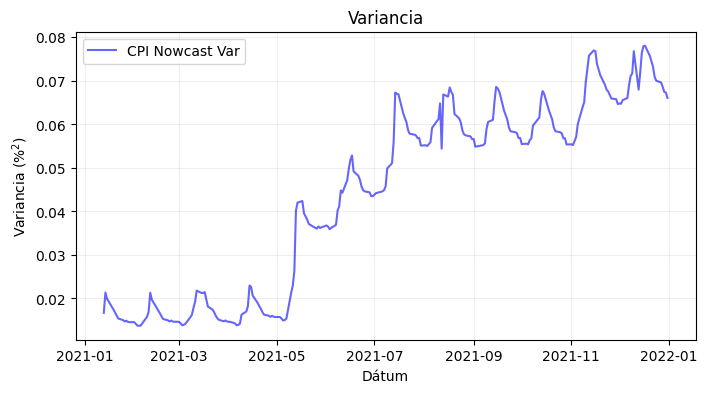

In [22]:
df_zoom = df_InflationAE.loc['2021-01-01':'2021-12-31']

# Ábrázolás: RMSE alakulása különböző intervallumok mellett
plt.figure(figsize=(8, 4))
plt.plot(df_zoom['RMSE_CPI'], label='1 nap alapján', color='green', alpha=0.6)
plt.plot(df_zoom['RMSE_CPI2'], label='5 nap alapján', color='red', alpha=0.6)
plt.plot(df_zoom['RMSE_CPI3'], label='7 nap alapján', color='blue', alpha=0.6)
plt.grid(True, alpha=0.2)
plt.legend(title='CPI RMSE')
plt.xlabel('Dátum')
plt.ylabel('Szórás (%)')
plt.savefig('FRED_Inflacio_RMSE.pdf', bbox_inches='tight')
plt.show()

# Ábrázolás: variancia alakulása a választott +- 2 napos intervallum esetén
plt.figure(figsize=(8, 4))
plt.plot(df_zoom['CPI Nowcast Var'], label='CPI Nowcast Var', color='blue', alpha=0.6)
plt.title('Variancia')
plt.grid(True, alpha=0.2)
plt.legend()
plt.xlabel('Dátum')
plt.ylabel(r'Variancia (%$^2$)')
plt.savefig('FRED_Infalcio_Var.pdf', bbox_inches='tight')
plt.show()

# Adatbázis mentése

In [23]:
df_InflationAE =  df_InflationAE.rename(columns = {'CPI Nowcast': 'CPI - Expectation','Actual CPI': 'CPI - Actual','CPI Nowcast Var': 'CPI_Var'})

df_Inflation_data = df_InflationAE[['CPI - Actual','CPI - Expectation','CPI_Var']]
display(df_Inflation_data)

df_Inflation_data.to_csv('df_Inflation_data.csv', index=True)

,CPI - Actual,CPI - Expectation,CPI_Var
Date,,,
2013-09-17,0.180280,0.272673,0.110283
2013-09-18,0.180280,0.272673,0.110283
2013-09-19,0.180280,0.272673,0.110283
2013-09-20,0.180280,0.272673,0.110283
2013-09-23,0.180280,0.272673,0.110283
...,...,...,...
2026-02-09,0.307355,0.134979,0.006535
2026-02-10,0.307355,0.134979,0.006651
2026-02-11,0.307355,0.134979,0.006866
